In [1]:
import numpy as np, pandas as pd
from sklearn.datasets import make_blobs

In [2]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

2026-04-12 12:34:03.606249: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-12 12:34:03.940959: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-12 12:34:03.941076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-12 12:34:03.947460: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-12 12:34:03.989406: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-12 12:34:03.991457: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [3]:
X, y = make_blobs(n_samples=300, n_features=2, centers=2, cluster_std=2.5, random_state=2)
X_train, y_train = X[:100, :], y[:100]

In [4]:
import matplotlib.pyplot as plt
plt.style.use('default')

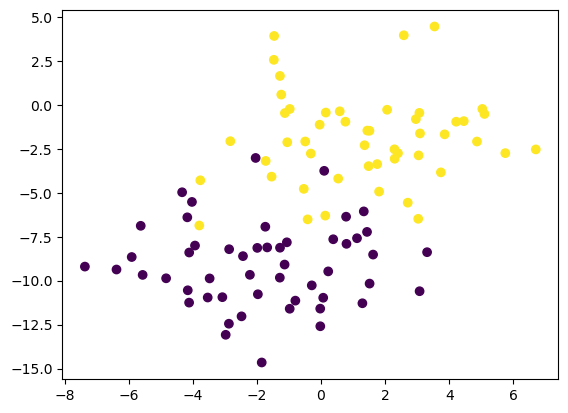

In [5]:
plt.scatter(X_train[:, 0],X_train[:, 1], c=y_train)

In [6]:
model = Sequential()

In [7]:
model.add(Input(shape= (2,)))
model.add(Dense(2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 6         
                                                                 
 dense_1 (Dense)             (None, 1)                 3         
                                                                 
Total params: 9 (36.00 Byte)
Trainable params: 9 (36.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
model.get_weights()

[array([[0.8532673, 0.8117887],
        [0.5785948, 0.5590526]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.277129 ],
        [ 1.1900617]], dtype=float32),
 array([0.], dtype=float32)]

In [10]:
initial_weights = model.get_weights()
initial_weights

[array([[0.8532673, 0.8117887],
        [0.5785948, 0.5590526]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.277129 ],
        [ 1.1900617]], dtype=float32),
 array([0.], dtype=float32)]

In [11]:
print(type(initial_weights))
len(initial_weights)

<class 'list'>


4

In [12]:
initial_weights[0] = np.zeros_like(model.get_weights()[0])
initial_weights[1] = np.zeros_like(model.get_weights()[1])
initial_weights[2] = np.zeros_like(model.get_weights()[2])
initial_weights[3] = np.zeros_like(model.get_weights()[3])
model.set_weights(initial_weights)
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [13]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [14]:
model.fit(X, y, epochs=44, validation_split=0.2, verbose=1)

Epoch 1/44


2026-04-12 12:34:32.672879: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type CPU is enabled.


8/8 [==============================] - 8s 359ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/44
8/8 [==============================] - 1s 141ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/44
8/8 [==============================] - 1s 153ms/step - loss: 0.6931 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/44
8/8 [==============================] - 1s 82ms/step - loss: 0.6931 - accuracy: 0.5000 - val_loss: 0.6930 - val_accuracy: 0.5000
Epoch 5/44
8/8 [==============================] - 1s 129ms/step - loss: 0.6930 - accuracy: 0.5000 - val_loss: 0.6928 - val_accuracy: 0.5000
Epoch 6/44
8/8 [==============================] - 1s 120ms/step - loss: 0.6927 - accuracy: 0.5000 - val_loss: 0.6925 - val_accuracy: 0.5000
Epoch 7/44
8/8 [==============================] - 1s 113ms/step - loss: 0.6923 - accuracy: 0.5000 - val_loss: 0.6920 - val_accuracy: 0.5000
Epoch 8/44
8/8 [================

In [15]:
from mlxtend.plotting import plot_decision_regions

9600/9600 [==============================] - 212s 22ms/step


<Axes: >

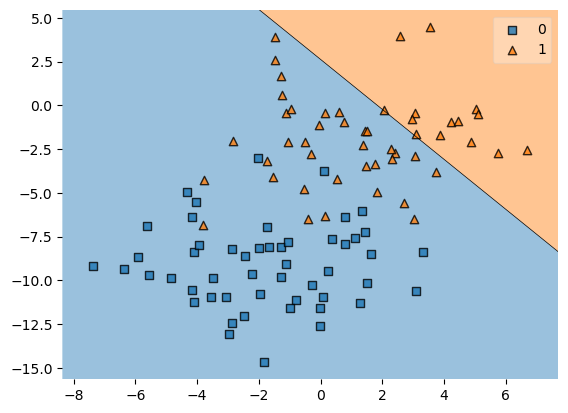

In [16]:
plot_decision_regions(X_train, y_train, clf = model)

In [17]:
model.get_weights()

[array([[-0.45433363, -0.45433363],
        [-0.3182537 , -0.3182537 ]], dtype=float32),
 array([-0.47264412, -0.47264412], dtype=float32),
 array([[-0.290103],
        [-0.290103]], dtype=float32),
 array([0.1236966], dtype=float32)]

# With sigmoid, All the nodes will act as a single node and'll plot a linear decission boundry bacause all the weight in a weight matrix of every feature are getting updated with the same value as input for next node. So each feature has a weights metrix that has identical values, but each weight matrix is different from other weight metrices.